In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [3]:
from sklearn.metrics import mean_squared_error, r2_score


SVR Results
MSE: 0.3551984619989418
R2: 0.7289407597956463


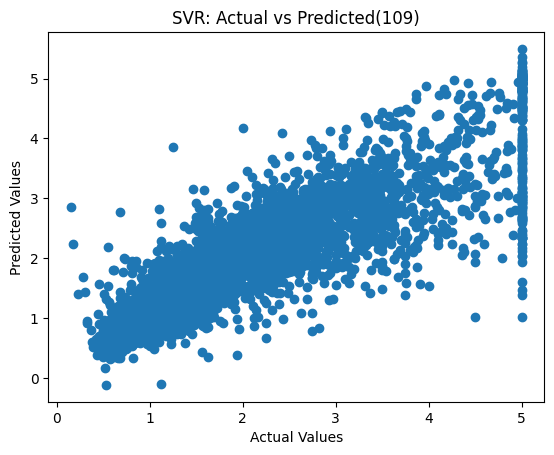

In [5]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

svr_preds = svr.predict(X_test)

svr_mse = mean_squared_error(y_test, svr_preds)
svr_r2 = r2_score(y_test, svr_preds)

print("\nSVR Results")
print("MSE:", svr_mse)
print("R2:", svr_r2)

plt.figure()
plt.scatter(y_test, svr_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted(109)")
plt.show()


Decision Tree Results
MSE: 0.4942716777366763
R2: 0.6228111330554302


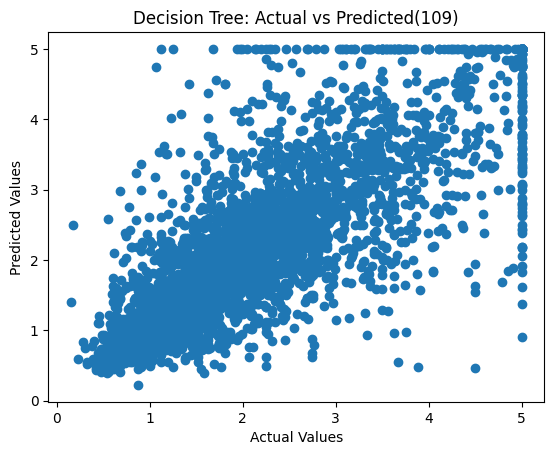

In [7]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print("\nDecision Tree Results")
print("MSE:", dt_mse)
print("R2:", dt_r2)

plt.figure()
plt.scatter(y_test, dt_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted(109)")
plt.show()

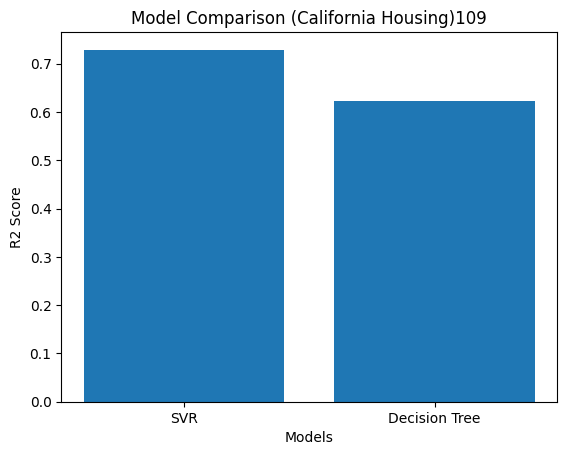

In [8]:
models = ["SVR", "Decision Tree"]
r2_scores = [svr_r2, dt_r2]

plt.figure()
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (California Housing)109")
plt.show()